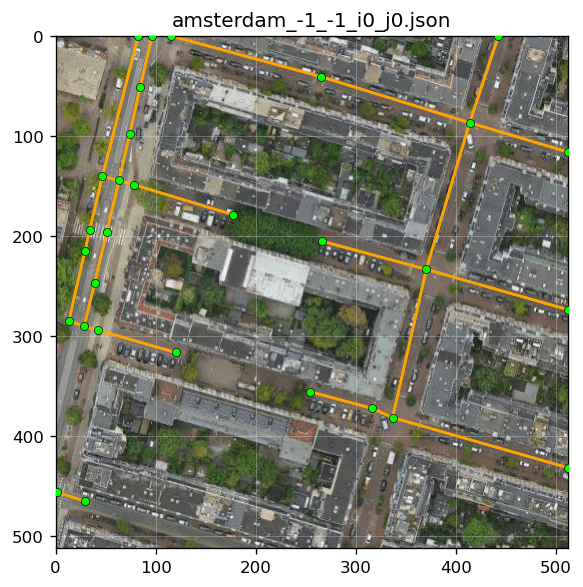

In [ ]:
import json
from PIL import Image
import matplotlib.pyplot as plt

def visualize_chip(gt_path, node_size=24, edge_lw=1.6,
                   edge_color="orange", node_color="lime"):
    with open(gt_path) as f:
        gt = json.load(f)

    img = Image.open(gt["image_path"])
    W = H = gt["crop"]["out_size"]

    pos = {n["idx"]: (n["x"], n["y"]) for n in gt["nodes"]}

    fig, ax = plt.subplots(figsize=(5,5), dpi=120)
    ax.imshow(img, extent=[0, W, 0, H], origin="upper")

    # edges 
    for e in gt["edges"]:
        x1, y1 = pos[e["src_idx"]]
        x2, y2 = pos[e["dst_idx"]]
        ax.plot([x1, x2], [y1, y2], lw=edge_lw, color=edge_color, alpha=0.95)

    # nodes 
    if pos:
        xs, ys = zip(*pos.values())
        ax.scatter(xs, ys, s=node_size, color=node_color,
                   edgecolors="black", linewidths=0.4, zorder=3)

    ax.set_xlim(0, W)
    ax.set_ylim(H, 0) 
    ax.set_aspect("equal")
    ax.grid(color="white", alpha=0.25, lw=0.6)
    ax.set_title(gt_path.split("/")[-1])
    plt.tight_layout()
    plt.show()

# Example:
visualize_chip("data/labels/amsterdam_-1_-1_i0_j0.json")
#visualize_chip("data/labels/tokyo_-1_-1_i0_j0.json")